In [1]:
import sys
import os
import importlib

parent = os.path.dirname(os.getcwd())
sys.path.insert(0, parent)

from Helpers import loadData, multiplot, sphereMask, saveData, chunker, unchunker, kernelPad
importlib.reload(sys.modules['Helpers.chunker'])
importlib.reload(sys.modules['Helpers.unchunker'])
importlib.reload(sys.modules['Helpers.kernelPad'])
importlib.reload(sys.modules['Helpers'])

import h5py
import matplotlib.pyplot as plt
import numpy as np
import stackview
from scipy.ndimage import zoom

In [ ]:
name = 'Cycle1s1'
path = rf'C:\Users\Lab User\Desktop\ModernExperiments\exp_232\{name}.hdf5'
with h5py.File(path,"r") as f:
    print(list(f['RawData'].keys()))
    data = f['RawData'][name][()]
    sz = data.shape
    print(sz)

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (3357662022.py, line 2)

In [3]:
mag = 0.25

zData = np.zeros(shape=(int(sz[0]),int(sz[1]*mag),int(sz[2]*mag)))
for i in range(sz[0]):
    img = zoom(data[i,:,:],mag)
    zData[i,:,:] = img

print(np.shape(zData))

(861, 304, 256)


In [4]:
fzData = zoom(data,mag)

In [5]:
stackview.orthogonal(fzData, continuous_update=True)

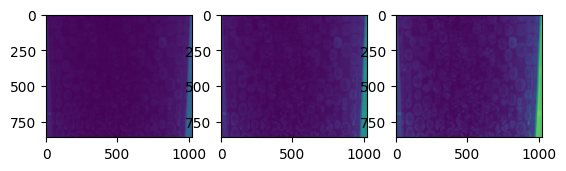

In [8]:
p=200
fig,axs = plt.subplots(1,3)
axs[0].imshow(data[:,p,:])
axs[1].imshow(data[:,p+1,:])
axs[2].imshow(data[:,p+2,:])